# Introduction to Neural Network Classification Part 2

In my part 1 , I talked a lot about binary classification. In this article, I'm going to talk about multi-class classification.

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

**You can find all my articles and code on**

- [Deep Learning With Tensorflow](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),

**If you are new to Machine learning, I also have a github for begennier machine learning.**

- [Machine Learning Zero to Hero](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero)

**Pre-requisites**

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.
- Basics Tensorflow and keras terminologies.
- Basics of Neural Network.
- [Read the previous article](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow/blob/main/pdfs/4_Neural_Network_Classification.pdf).

**Installations**

We need to install Tensorflow. To do so, we will use the following command:

```bash
    pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.

# Get the Data

I'll use the mnist dataset for this article.

If you've installed `tensorflow` properly then you can use the following command to download the dataset.

Altough I'll be talking about the data a lot but if you want you can see details about the dataset [here](https://www.tensorflow.org/datasets/catalog/mnist).



In [1]:
import tensorflow as tf
from keras.datasets import mnist

2026-09-11 10:41:14.982522: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

We can directly load the dataset and the dataset is already split for us.

This dataset contains the images of the digits from 0 to 9. Each picture is a `28x28` image. 

Let's see the size of the dataset.

In [3]:
len(x_train)

60000

In [4]:
len(x_test)

10000

The training set has 60000 images and set testing set has 10000 images. 

Let's see how many categories we have in the training set.

In [5]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

As you can see the target variable has values from 0 to 10, That means 10 classes.

So, Our objective is very simple, we want to classify the images into 10 classes.

But how does oue data look like?

In [6]:

print(f'the shape of each image is {x_train[0].shape}')

x_train[0]

the shape of each image is (28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

It's a 28 by 28 2D matrix.

UMMMMMM... 

What does the values represent?

We might be able to figure out something if we see the range of values.

In [7]:
print(f'max value of each image is {np.max(x_train[0])}')
print(f'min value of each image is {np.min(x_train[0])}')

max value of each image is 255
min value of each image is 0


Owh, 0 to 255. I want you to figure out what this means.

I hope you did try to figure this out on your own.

The values represent the color of the pixels in the image. We can plot this using the following code:

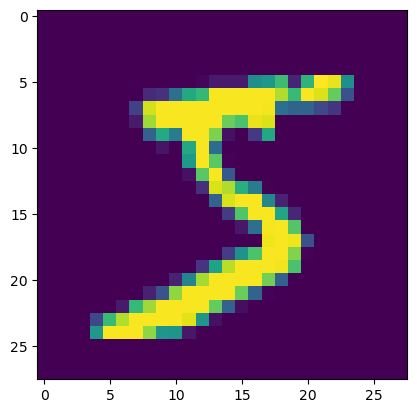

In [8]:
import matplotlib.pyplot as plt

image = x_train[0]

plt.imshow(image)


Would you look at that!

it's an image of `5`.

Let's see if I'm right.

In [9]:
y_train[0]

np.uint8(5)

let's try another one.

This is the image of 2


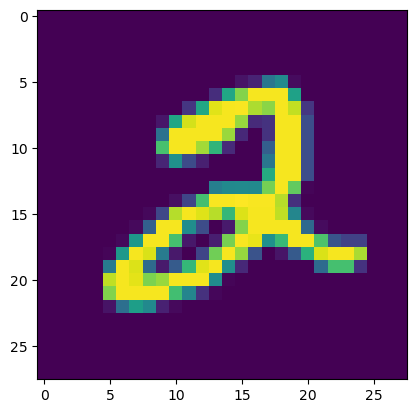

In [10]:
image = x_train[5]

plt.imshow(image)

print(f'This is the image of {y_train[5]}')

Now here's the color might look a bit weird, But the main color is in black and white.

I'll write a simple script to show different images and their corresponding labels with correct color.

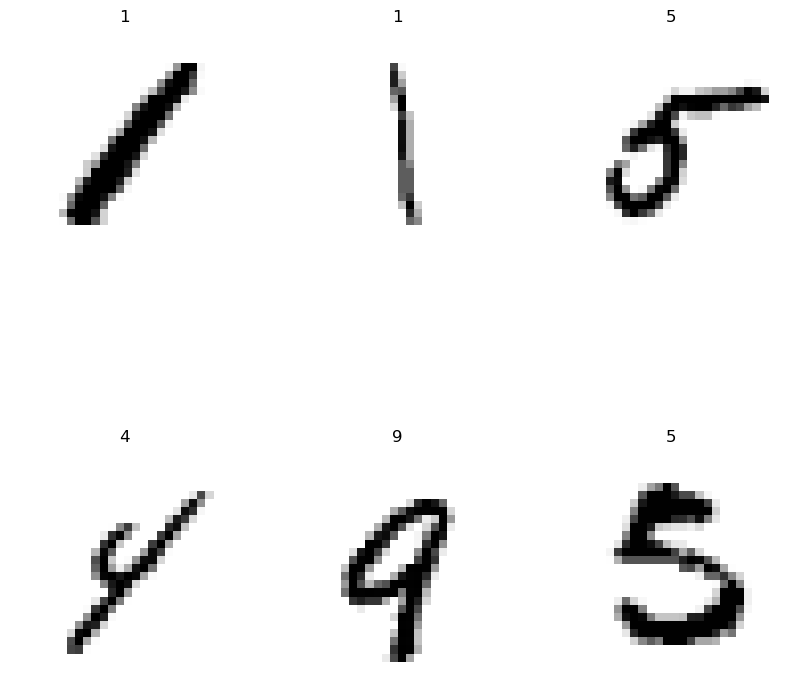

In [11]:
import random 

plt.figure(figsize=(10,10))

for i in range(6):
    ax = plt.subplot(2,3,i+1)
    rand_index = random.choice(range(len(x_train)))
    plt.imshow(x_train[rand_index], cmap=plt.cm.binary)
    plt.title(y_train[rand_index])
    plt.axis('off')
    
plt.show()

Not bad! not bad!

We have a lot of hand written digits and it seems like they are all correctly classified.

And now for the fun part, let's try to classify the digits using a neural network.

# Building a Multi-Class Classification Model

Here's what we did for binary classification:

- Input Layer.
- Hidden Layer.
- Output Layer of only one neuron.

In multi-class classification, we predict multiple classes. So, one neuron in the output layer will not be enough. We need to have multiple neurons in the output layer.

Rule of thumb is **one neuron per class**.

In the output layer, we have to set one neuron per class. 

There's another thing we need to change that is the activation function of the output layer.

For binary classification, we use the sigmoid function. But for multi-class classification, we have to use `softmax` function.

## What is the `softmax` function?

While the sigmoid function squashes a single number into a probability between 0 and 1, it only works when choosing between two options (Yes/No). When we have multiple neurons in our output layer, each neuron outputs its own raw score (called a logit). These raw numbers can be anything—negative, positive, small, or massive.

The softmax function takes all of these raw scores together and transforms them into a probability distribution. It does this by enforcing two strict rules:

   1. Every individual class gets a probability between 0 and 1 (0% to 100%).
   2. All the probabilities must add up to exactly 1 (100%).

The math is pretty simple:

$$
\text{Softmax}(x_1, x_2, x_3, \dots, x_n) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}} 
$$

## How Softmax Works: An Example
Imagine we are building a model to classify images of pets into three classes: Dog, Cat, or Bird. Because we have 3 classes, our output layer has 3 neurons.
When we feed a picture of a fuzzy animal into the model, the final layer outputs these raw scores (logits):

* Dog neuron: 2.0
* Cat neuron: 1.0
* Bird neuron: -1.0

Looking at these raw numbers, the model clearly thinks it's a dog, but these aren't probabilities. To convert them, Softmax performs a 2-step calculation:

### Step 1: Turn everything positive using Exponents ($e^x$)
To get rid of negative numbers (like the Bird's -1.0) and widen the gap between high and low scores, Softmax raises Euler's number ($e \approx 2.718$) to the power of each raw score:

* Dog ($e^{2.0}$): $\approx 7.39$
* Cat ($e^{1.0}$): $\approx 2.72$
* Bird ($e^{-1.0}$): $\approx 0.37$

Total Sum of Exponents: $7.39 + 2.72 + 0.37 = \mathbf{10.48}$

**Why Exponents of $e$? Why not $2$ or $3$?**

Why choose this random, messy decimal ($e \approx 2.718$) instead of clean, friendly integers like $2$ or $3$?

The short answer is: You could technically use 2 or 3 to turn the numbers positive, but we use Euler's number because of its unique properties in calculus.

In neural networks, everything relies on calculating derivatives (gradients) during backpropagation so the model can learn. Euler’s number makes the calculus incredibly clean and efficient.

**The Magic of Calculus (The Biggest Reason)**

In calculus, Euler’s number $e$ has a legendary superpower: it is the only function whose derivative is exactly itself.

$$
\frac{d}{dx}(e^x) = e^x 
$$ 

If you were to use $2^x$ or $3^x$, their derivatives are messy and require multiplying by an extra scaling factor every single time:

* Derivative of $2^x = 2^x \cdot \ln(2)$
* Derivative of $3^x = 3^x \cdot \ln(3)$

Because a neural network has to calculate derivatives for millions of parameters across thousands of training steps, using $2$ or $3$ would force the computer to constantly multiply by these extra natural log fractions ($\ln(2)$ or $\ln(3)$). Using $e$ strips away all that mathematical clutter, making the code run significantly faster and cleaner.

**The Perfect Cancel-Out with Cross-Entropy**

When you train a multi-class model, you pair the softmax activation function with a loss function called `Categorical Cross-Entropy`.

Cross-Entropy relies heavily on the natural logarithm ($\ln$), which is a logarithm with a base of... you guessed it, $e$.

Because the logarithm in the loss function and the exponent in the Softmax function both use the base $e$, they perfectly cancel each other out when calculating the gradient:

$$
\ln(e^x) = x
$$ 

This beautiful mathematical harmony completely eliminates the risk of complex fractions and prevents gradients from slowing down or glitching out during training. It ensures that the "kick" the optimizer gives the weights is perfectly proportional to how wrong the model's guess was.

So, the simple answer to why use $e^x$? By using $e$, the math beautifully simplifies during training, allowing the computer to calculate weight updates incredibly fast without getting bogged down by messy fractions.

### Step 2: Normalize to get the Percentage

Next, it divides each individual score by the total sum ($10.48$). This yields the final, clean probabilities:

* Dog Probability: $7.39 / 10.48 = \mathbf{0.705}$ (70.5%)
* Cat Probability: $2.72 / 10.48 = \mathbf{0.260}$ (26.0%)
* Bird Probability: $0.37 / 10.48 = \mathbf{0.035}$ (3.5%)


### The Final Prediction

Just like BinaryAccuracy used a 0.5 threshold for a single neuron, a multi-class model simply looks for the highest probability in the group (a function called argmax). In this case, the model confidently outputs Dog with 70.5% certainty.



So, let's make a model.

In [12]:
from keras import models, activations, optimizers, layers, losses, metrics

model_1 = models.Sequential([
    layers.Input(shape=(28,28)),
    layers.Dense(5, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_1.compile(
    optimizer=optimizers.Adam(),
    loss=losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

model_1.fit(
    x_train, y_train,
    epochs=10,
)

I0000 00:00:1789101693.309043   35318 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


Epoch 1/10


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32,), output.shape=(32, 28, 10)

And we have an error.

`Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32,), output.shape=(32, 28, 10)`

What does this mean?

The target is a vector of 32 elements, and the output is a 32 x 28 x 10 matrix. The error is telling us that the target and output have different ranks.

If you go to the `CategoricalCrossentropy` function [docs](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy). You will see that when you are using this class when there's more than one output, it expects the target labels to be a one-hot encoded vector.
No worries, we can fix this by using the `SparseCategoricalCrossentropy` class.

In [ ]:
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model_1.fit(
    x_train,
    y_train,
    epochs=10,
)

Epoch 1/10


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(32,), output.shape=(32, 28, 10)

Okay, now we have this `ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(32,), output.shape=(32, 28, 10)`

The problem is not with the `model.fit()` function here. This is connected to the Input layer of the model. 

When you pass a `28x28` image to the model, The Dense layer doesn't know how to process it. It doesn't see a 2D image. It can only take a vector sequence.

So, We have to make our 2D image into a vector sequence.

Let's say we have a 2D vector like below:

In [31]:
sample = np.random.randint(10,size=(3,3))
sample

array([[8, 8, 3],
       [6, 9, 2],
       [3, 7, 6]])

What happends if we want to make the above 2D matrix into a vector without the loss of information?

We can simply put each row side by side and get a vector right?

In [23]:
sample.flatten()

array([1, 5, 0, 6, 1, 9, 7, 3, 0])

Now, if you look the rows are now the next values of their previous row.

And the ammount of information is still the same.

This is called **flattening**.

SO, before the values from input layers is fed to the first Dense layer, we have to flatten the input.

In [24]:
from keras import models, activations, optimizers, layers, losses, metrics

model_1 = models.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(5, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_1.compile(
    optimizer=optimizers.Adam(),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model_1.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.1122 - loss: 2.3578 - val_accuracy: 0.1135 - val_loss: 2.3011
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 969us/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1135 - val_loss: 2.3013
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 964us/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012


`Flatten layers` flatten the input data to 1D and now our model is training properly.

Let's see what actually happends when we flatten an image.

In [25]:
image.flatten().shape

(784,)

It becomes an array of `784` values. Exactly 28x28 pixels.

Also, I've added the `validation_data` argument to the `model.fit()` method. 

By using this mathod we can check the accuracy of the model on the unseen data. This helps in knowing if the model is generalizing well or not and also helps us in understanding the model's performance better.

For the above model it seems the model is actually just BAD. But I think training the model for longer can improve the model's accuracy.

Let's have a look what model currently looks like.

In [26]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,047 (47.06 KB)

 Trainable params: 4,015 (15.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,032 (31.38 KB)

In total, 12,047 parameters are being trained. Only two layers still some many parameters? How did that happen? The answer is pretty simple so I wont tell you. Find it out yourself.

Now, one thing we can try is normalizing the data.

Every image is a `(28, 28)` matrix with values from 0 to 255 representing the intensity of each pixel. 

> Neural netowrks can be very sensitive to the scale of the data. And they fit well with normilized data.

So, I will scale the data to be between 0 and 1 using `min-max` normalization.

I wont use any fancy libraries to do this, just use numpy.

In [27]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [28]:
x_train_norm.min(), x_train_norm.max()

(np.float64(0.0), np.float64(1.0))

The range is from 0 to 1. Done!

How I did that?

Simple, the `min-max` normalization function is $\frac{x - \min(x)}{\max(x) - \min(x)}$. 

Minimun of the data is 0, So, the function is simply $\frac{x}{max(x)}$.

Maximum of the data is 255, So, the function is simply $\frac{x}{255}$.

That's why I just divided the data by 255.

So, let's see how the model performs on normalized data.

In [29]:
from keras import models, activations, optimizers, layers, losses, metrics

model_2 = models.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(5, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_2.compile(
    optimizer=optimizers.Adam(),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model_2.fit(
    x_train_norm, y_train,
    epochs=5,
    validation_data=(x_test_norm, y_test)
)

Epoch 1/5


2026-09-11 10:42:46.741882: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
2026-09-11 10:42:46.912114: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7383 - loss: 0.8272 - val_accuracy: 0.8480 - val_loss: 0.5358
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8535 - loss: 0.5126 - val_accuracy: 0.8624 - val_loss: 0.4833
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8661 - loss: 0.4682 - val_accuracy: 0.8740 - val_loss: 0.4540
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8722 - loss: 0.4470 - val_accuracy: 0.8717 - val_loss: 0.4493
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 982us/step - accuracy: 0.8758 - loss: 0.4329 - val_accuracy: 0.8762 - val_loss: 0.4312


WHAAT! 

**85+% accuracy!!!**

Just after normalizing.

In model 1, It was guessing and guessing very bad indeed. But in model to an exact copy of model 1, The onlt change was normalization and The model has an accuracy of 85%. And Same on the validation set as well.

Let's see the loss curves of these models


<Axes: >

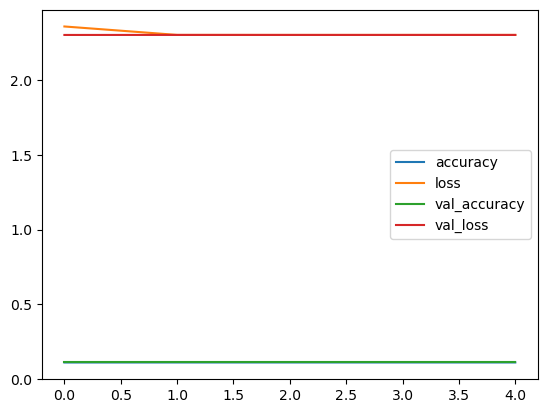

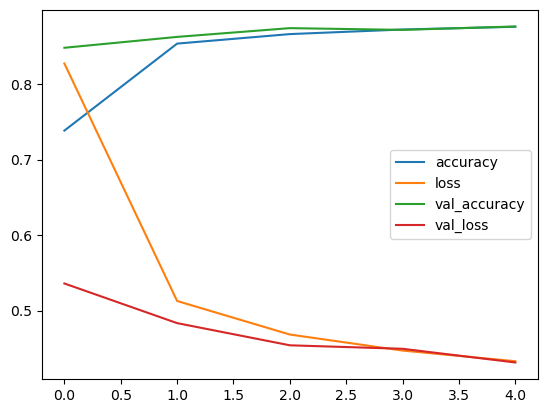

In [30]:
import pandas as pd

pd.DataFrame(
    model_1.history.history
).plot()

pd.DataFrame(
    model_2.history.history
).plot()


Would you look at that... Huge difference between these two models even though everything is the same exept training feature data.

> When You are comparing two models, you should always compare the performance of the model on the same criteria.

Now, let's properly evaluate the second model.

# Evaluation

We can simple predict the class of the test data using the trained model.

In [49]:
preds = model_2.predict(x_test_norm)
preds

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[4.97889159e-05, 5.32655093e-08, 2.72502075e-06, ...,
        9.94925499e-01, 3.48065782e-06, 1.20922236e-03],
       [1.76667148e-04, 2.00976004e-07, 9.99233365e-01, ...,
        3.69449920e-14, 1.16299634e-04, 1.95223590e-12],
       [2.65319686e-05, 9.62961376e-01, 1.64216440e-02, ...,
        1.23514037e-03, 6.06656261e-03, 2.47214362e-03],
       ...,
       [1.19961896e-07, 2.74351096e-05, 3.46908315e-08, ...,
        8.18537410e-06, 2.08582096e-02, 1.69130966e-01],
       [1.27075585e-02, 3.32055379e-06, 1.56312645e-03, ...,
        4.23843667e-05, 1.56102940e-01, 7.69981369e-03],
       [1.26086979e-05, 1.97843006e-10, 2.25359454e-05, ...,
        6.43523456e-15, 2.19896765e-06, 5.26783651e-11]],
      shape=(10000, 10), dtype=float32)

What is this?

Im given a 2D array? But why?

> Always remember the scalling of the data. if You pass the main data to the model, it will not work properly because the model is trained on normalized data.

In [50]:
preds[0], preds[0].shape

(array([4.9788916e-05, 5.3265509e-08, 2.7250207e-06, 3.6262181e-03,
        1.1433993e-08, 1.8307105e-04, 5.4302500e-12, 9.9492550e-01,
        3.4806578e-06, 1.2092224e-03], dtype=float32),
 (10,))

Every index of prediction is an array of shape (10,). 

This is because of the output layer. As we have set neurons for the output layer to be 10, the model predicts 10 classes and gives us a softmax probability distribution for each of the 10 classes every time. 

Each value represents the probability of the class being present in the image.

> The values each class will range from 0 to 1. 1 meaning 100% probability of the class being present in the image.

So, if we find the index of the class with the highest probability, we can say that the model predicts the image to be of that class.

In [51]:
np.argmax(preds[0])

np.int64(7)

So, let's see if it really is 7 from the y_test array.

In [52]:
y_test[0]

np.uint8(7)

YES!

So, the model is predicting the correct class for the first test image. But can we do this for 10000 images manually?

Because we only need the index of the max probability for each image, WE can just make a loop and get the index of the max probability for each image.

In numpy, we dont even need a loop. We canjust use the `argmax` function and set the axis to 1.

In [53]:
preds = np.argmax(preds, axis=1)
preds

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

Now, we have predictions in the correct format.

So, Now we can make a confusion matrix to see the performance of the model for each class.

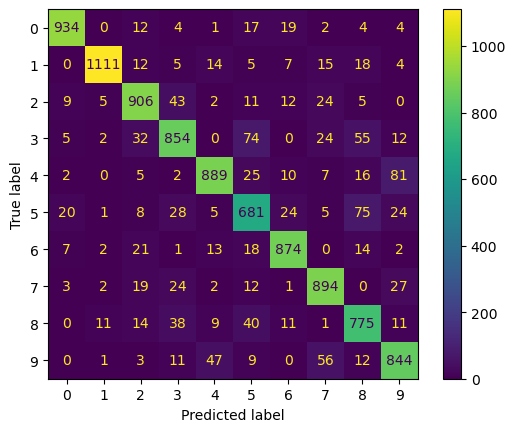

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(preds, y_test)

Would you look at that!

ALmost every class prediction looks great except for 5. The model is doing a lot of false predictions for the class.

Let's see a classification report for the model.


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       980
           1       0.93      0.98      0.96      1135
           2       0.89      0.88      0.88      1032
           3       0.81      0.85      0.83      1010
           4       0.86      0.91      0.88       982
           5       0.78      0.76      0.77       892
           6       0.92      0.91      0.92       958
           7       0.91      0.87      0.89      1028
           8       0.85      0.80      0.82       974
           9       0.86      0.84      0.85      1009

    accuracy                           0.88     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.88      0.88      0.88     10000



Overall Accuracy is: 0.88

F1-score is a little low. 0.87 not by much from the accuracy. This mainily because of the small imbalance in the dataset and 5 having the lowest accuracy.

Even though the accuracy is 88% and this is from a very small model and normalized data and the model has only been trained for 5 epochs. If the model was trained for more epochs and a little more complex Im sure It would've gotten better.

Now, one thing I want to see is if our model can classify images randomly. This is just a fun visualization I like to do when I'm working with a ny image classification model.

In [86]:
def plot_random_image_classification(model, images, labels, num_images=10):
    i = random.randint(0, len(images) - 1)

    target_image = images[i]
    target_label = labels[i]

    pred = model.predict(target_image.reshape(1, 28, 28))
    pred_label = np.argmax(pred)

    plt.imshow(target_image, cmap='gray')

    if pred_label == target_label:
        plt.title('Correct Prediction', color='green')
    else:
        plt.title('Wrong Prediction', color='red')

    plt.xlabel(f"Predicted Label: {pred_label} - {(pred[0][pred_label])*100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


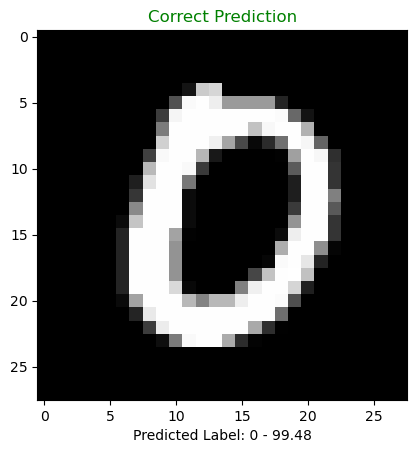

In [105]:
plot_random_image_classification(model_2, x_test_norm, y_test)

You can reuse this function later for other image classification tasks.

Before ending this article. I want to answer one question.

What is our Model Actually Learning?

As you know a neural network is a collection of perceptron connected with each other layer by layer. Each perceptron represents a simple equation. And when we connect all of them togather we get a nice long equation that have weights and biases.

We can actually recreate the whole equation of our model through manual tedious calculations. But that will be in most of the cases very time wasting.

We can do a better job by if we can just take a look at those parameters.

In [106]:
model_2.layers

[<Flatten name=flatten_3, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>]

We can directly get each layers of our model as a array of layers. 

In tensorflow we can also go inside of these layers and see their weights and biases.

In [112]:
weights, biases = model_2.layers[1].get_weights()

weights, weights.shape

(array([[ 0.00260421,  0.01649264,  0.00615953, -0.05802117,  0.02855626],
        [-0.00548527,  0.06108232,  0.00908612, -0.03729928,  0.03528595],
        [-0.05369082, -0.02452326, -0.0358103 ,  0.07234433,  0.03303658],
        ...,
        [-0.02859505, -0.07046048, -0.08010679,  0.04974975,  0.01841976],
        [ 0.00532298, -0.00032334,  0.06061716, -0.07351939, -0.0061508 ],
        [-0.02564703, -0.06044169, -0.00683291, -0.04386911,  0.05809161]],
       shape=(784, 5), dtype=float32),
 (784, 5))

`get_weights()` mathod returns both the weight and bias values for each neuron in the layer.

For our first dense layer we can see the weight and bias values for each neuron. The shape of the weight matrix is (784, 5) because after flattening eaching pixel is now passed as an input and each pixel will have a weight and 5 is for 5 neurons in the first layer.

So, each pixel has 5 weights going into 5 neurons.

If we take a look at the bias values:

In [113]:
biases, biases.shape

(array([ 0.06902113,  0.40507412,  0.33189902, -0.22540154,  0.02788919],
       dtype=float32),
 (5,))

Each neuron of the layer will attach an extra value and that is why we have only 5 biases in this layer because this layer has only 5 neurons.

And now, you can recreate the whole model in mathematical form and very easily know what pattern the model is actually learning.

> Don't try it!!

One last thing. We can visulize the whole model witha simple command.

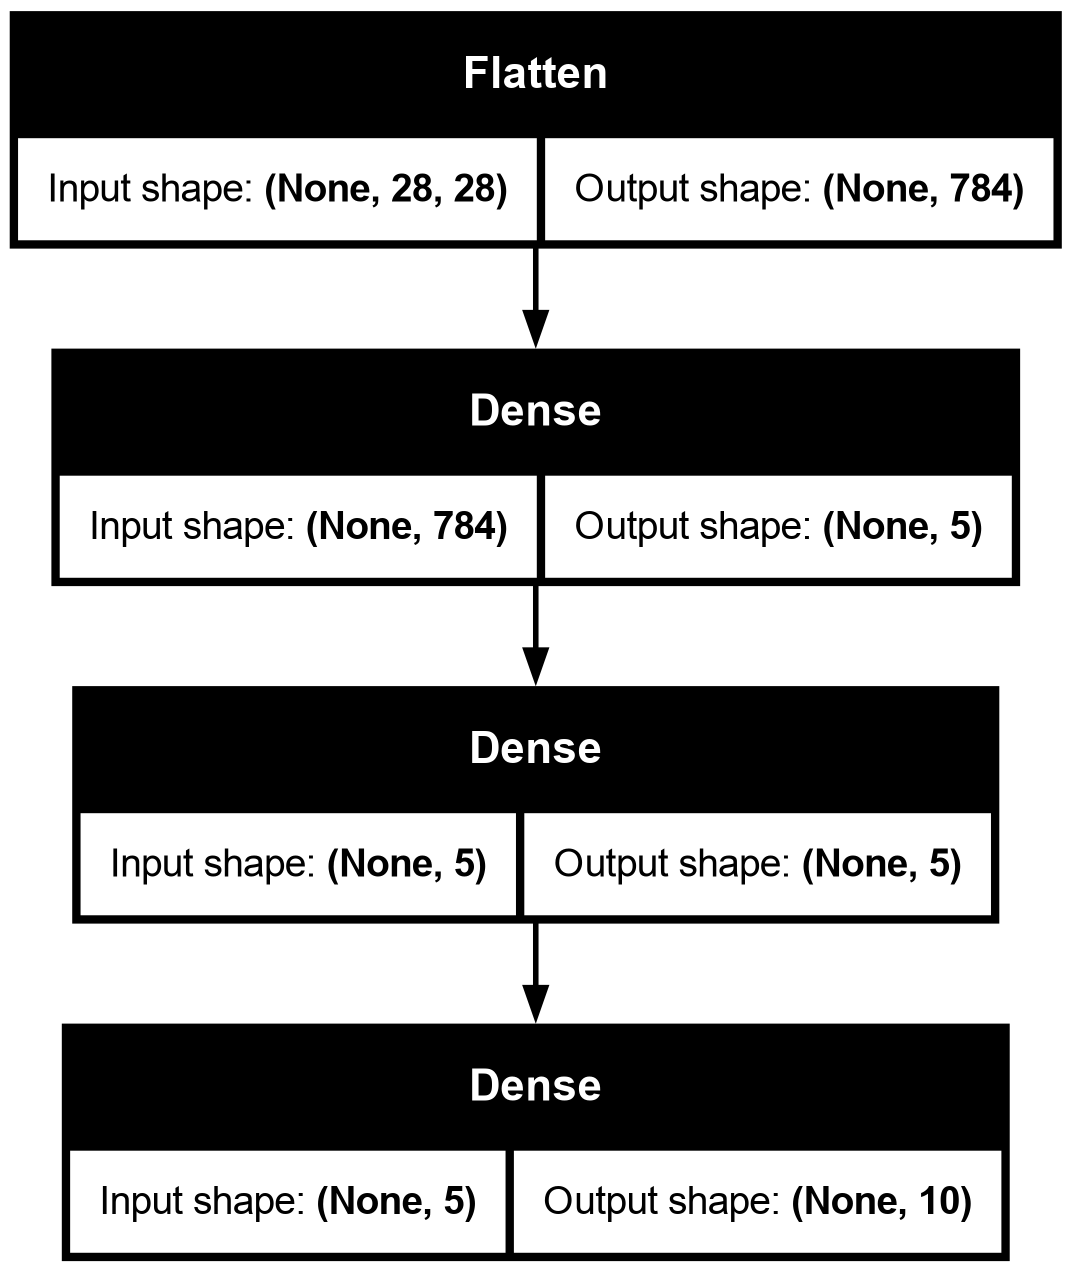

In [117]:
from keras.utils import plot_model

plot_model(model_2, show_shapes=True)

Nice!

That's it for this article.

I hope you liked it. A lot of work goes into writting these articles. Share, like and subscribe to my youtube channel to get more content like this.

# Conclusion

GOODBYE